<a href="https://colab.research.google.com/github/shoh0806/Deep-Learning-Project/blob/main/Cross_Attention_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 라이브러리 설치

In [1]:
!pip install transformers accelerate -q

# 2. 라이브러리 import, 시드 고정(Bert, Vit와 통일)

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel
from transformers import ViTModel, ViTImageProcessor

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

def set_seed(seed=42):                        # 승현님이 설정하신 조건과 같게 시드는 42로 설정하였습니다.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# 3. 구글 드라이브 연결 및 데이터 로드

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/clickbait_project'
CSV_PATH = f'{BASE_DIR}/dataset.csv'
IMG_DIR  = f'{BASE_DIR}/thumbnails'

df = pd.read_csv(CSV_PATH)

print(df.head())
print(df['label'].value_counts())

Mounted at /content/drive
      video_id                                              title  \
0  lepHJI4ze-w               I Bought 250 BANNED Amazon Products!   
1  ezwXAlJ5pAY  TikTok Wigofellas PRANKS on MOM - Wigofellas P...   
2  i6_OomloWUg  TikTok Wigofellas PRANKS on MOM - Wigofellas P...   
3  VvuuR7HifUY        Superheroes in Real Life Caught On Camera !   
4  uwIjrEbywnk  20 People You Won't Believe Existed Till You S...   

               thumbnail_path  label  
0  thumbnails/lepHJI4ze-w.jpg      1  
1  thumbnails/ezwXAlJ5pAY.jpg      1  
2  thumbnails/i6_OomloWUg.jpg      1  
3  thumbnails/VvuuR7HifUY.jpg      1  
4  thumbnails/uwIjrEbywnk.jpg      1  
label
0    1402
1    1110
Name: count, dtype: int64


# 4. 데이터셋 split

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(len(train_df), len(val_df), len(test_df))

# 승현님이 말씀해주신대로 random_state를 42로 설정하였습니다. 또한 데이터셋 split도 동일하게 진행하였습니다.(공정성 유지)

2009 251 252


# 5. Multimodal Dataset

In [5]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
image_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

class MultimodalDataset(Dataset):
    def __init__(self, df, tokenizer, image_processor, img_dir, max_len=64):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.img_dir = img_dir
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        title = str(row['title'])
        label = int(row['label'])
        video_id = row['video_id']

        text_inputs = self.tokenizer(
            title,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        img_path = f"{self.img_dir}/{video_id}.jpg"
        image = Image.open(img_path).convert("RGB")

        image_inputs = self.image_processor(
            images=image,
            return_tensors='pt'
        )

        return {
            'input_ids': text_inputs['input_ids'].squeeze(0),
            'attention_mask': text_inputs['attention_mask'].squeeze(0),
            'pixel_values': image_inputs['pixel_values'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

# 6. DataLoader

In [6]:
BATCH_SIZE = 16        # 배치 사이즈를 8로 한 이유는 GPU 메모리 때문입니다!
MAX_LEN = 128

train_dataset = MultimodalDataset(train_df, tokenizer, image_processor, IMG_DIR, MAX_LEN)
val_dataset   = MultimodalDataset(val_df, tokenizer, image_processor, IMG_DIR, MAX_LEN)
test_dataset  = MultimodalDataset(test_df, tokenizer, image_processor, IMG_DIR, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Dataset 준비 완료!")
print(f"train loader: {len(train_loader)}배치")

Dataset 준비 완료!
train loader: 126배치


# 7. Cross-Attention 모델(bert, vit 마지막 2개 layer만 오픈)

In [7]:
def freeze_backbone_except_last_layers(model, bert_unfreeze_layers=2, vit_unfreeze_blocks=2):
    """
    BERT와 ViT backbone은 대부분 freeze하고,
    마지막 일부 layer/block만 fine-tuning하도록 설정하는 함수
    """

    # ==============================
    # 1. BERT 전체 freeze
    # ==============================
    for param in model.bert.parameters():
        param.requires_grad = False

    # BERT 마지막 N개 encoder layer만 unfreeze
    for layer in model.bert.encoder.layer[-bert_unfreeze_layers:]:
        for param in layer.parameters():
            param.requires_grad = True

    # ==============================
    # 2. ViT 전체 freeze
    # ==============================
    for param in model.vit.parameters():
        param.requires_grad = False

    # ViT 마지막 N개 encoder block만 unfreeze
    for layer in model.vit.encoder.layer[-vit_unfreeze_blocks:]:
        for param in layer.parameters():
            param.requires_grad = True

    # ViT는 encoder 뒤에 layernorm이 있으므로 같이 열어주는 것이 좋음
    if hasattr(model.vit, "layernorm"):
        for param in model.vit.layernorm.parameters():
            param.requires_grad = True

In [8]:
class CrossAttentionClickbaitModel(nn.Module):
    def __init__(
        self,
        bert_name='bert-base-multilingual-cased',
        vit_name='google/vit-base-patch16-224',
        hidden_size=768,
        num_heads=8,
        dropout=0.3,
        freeze_backbone=False
    ):
        super().__init__()

        self.bert = BertModel.from_pretrained(bert_name)
        self.vit = ViTModel.from_pretrained(vit_name)

        self.text_to_image_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.image_to_text_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_t2i = nn.LayerNorm(hidden_size)
        self.norm_i2t = nn.LayerNorm(hidden_size)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 4, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2)
        )

        # BERT와 ViT는 마지막 2개 layer/block만 fine-tuning
        freeze_backbone_except_last_layers(
            self,
            bert_unfreeze_layers=2,
            vit_unfreeze_blocks=2
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        vit_outputs = self.vit(
            pixel_values=pixel_values
        )

        text_hidden = bert_outputs.last_hidden_state
        image_hidden = vit_outputs.last_hidden_state

        text_cls = text_hidden[:, 0, :]
        image_cls = image_hidden[:, 0, :]

        text_padding_mask = attention_mask == 0

        t2i_output, t2i_attn_weights = self.text_to_image_attn(
            query=text_hidden,
            key=image_hidden,
            value=image_hidden,
            need_weights=True,
            average_attn_weights=True
        )

        i2t_output, i2t_attn_weights = self.image_to_text_attn(
            query=image_hidden,
            key=text_hidden,
            value=text_hidden,
            key_padding_mask=text_padding_mask,
            need_weights=True,
            average_attn_weights=True
        )

        t2i_output = self.norm_t2i(t2i_output + text_hidden)
        i2t_output = self.norm_i2t(i2t_output + image_hidden)

        t2i_cls = t2i_output[:, 0, :]
        i2t_cls = i2t_output[:, 0, :]

        fused = torch.cat(
            [text_cls, image_cls, t2i_cls, i2t_cls],
            dim=1
        )

        fused = self.dropout(fused)
        logits = self.classifier(fused)

        return logits, t2i_attn_weights, i2t_attn_weights

# 8. 기존 BERT / ViT fine-tuned weight 불러오기

In [9]:
def load_backbone_weights(model, BASE_DIR):
    bert_path = f"{BASE_DIR}/mbert_best.pt"
    vit_path = f"{BASE_DIR}/vit_best.pt"

    if os.path.exists(bert_path):
        bert_state = torch.load(bert_path, map_location='cpu')
        bert_only = {
            k.replace("bert.", ""): v
            for k, v in bert_state.items()
            if k.startswith("bert.")
        }
        model.bert.load_state_dict(bert_only, strict=False)
        print("BERT fine-tuned weight loaded.")

    else:
        print("BERT weight not found. Using pretrained BERT.")

    if os.path.exists(vit_path):
        vit_state = torch.load(vit_path, map_location='cpu')
        vit_only = {
            k.replace("vit.", ""): v
            for k, v in vit_state.items()
            if k.startswith("vit.")
        }
        model.vit.load_state_dict(vit_only, strict=False)
        print("ViT fine-tuned weight loaded.")

    else:
        print("ViT weight not found. Using pretrained ViT.")

# 9. 모델 생성

In [10]:
model = CrossAttentionClickbaitModel(
    dropout=0.3,
    num_heads=8
).to(device)

load_backbone_weights(model, BASE_DIR)

print("Cross-Attention 모델 생성 완료!")
print(f"학습가능 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"전체 파라미터 수:     {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT fine-tuned weight loaded.
ViT fine-tuned weight loaded.
Cross-Attention 모델 생성 완료!
학습가능 파라미터 수: 35,442,434
전체 파라미터 수:     271,332,098


# 10. Optimizer, train / eval 함수

In [11]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=0
)

criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    preds = []
    targets = []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        logits, _, _ = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        preds += logits.argmax(dim=1).detach().cpu().tolist()
        targets += labels.detach().cpu().tolist()

    avg_loss = total_loss / len(loader)
    f1 = f1_score(targets, preds, average='macro')
    acc = accuracy_score(targets, preds)

    return avg_loss, f1, acc


def eval_epoch(model, loader, criterion):
    model.eval()

    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            logits, _, _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values
            )

            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds += logits.argmax(dim=1).cpu().tolist()
            targets += labels.cpu().tolist()

    avg_loss = total_loss / len(loader)
    f1 = f1_score(targets, preds, average='macro')
    acc = accuracy_score(targets, preds)

    return avg_loss, f1, acc, preds, targets

# 11. 학습

In [12]:
EPOCHS = 10
PATIENCE = 3

best_val_f1 = 0
patience_counter = 0

SAVE_PATH = f"{BASE_DIR}/cross_attention_v2_best.pt"

for epoch in range(EPOCHS):
    train_loss, train_f1, train_acc = train_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_f1, val_acc, _, _ = eval_epoch(
        model, val_loader, criterion
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  train loss: {train_loss:.4f} | f1: {train_f1:.4f} | acc: {train_acc:.4f}")
    print(f"  val   loss: {val_loss:.4f} | f1: {val_f1:.4f} | acc: {val_acc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print("  → best model saved")
    else:
        patience_counter += 1
        print(f"  → patience {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

Epoch 1/10
  train loss: 0.0211 | f1: 0.9939 | acc: 0.9940
  val   loss: 0.4381 | f1: 0.9158 | acc: 0.9163
  → best model saved
Epoch 2/10
  train loss: 0.0010 | f1: 0.9995 | acc: 0.9995
  val   loss: 0.4754 | f1: 0.9042 | acc: 0.9044
  → patience 1/3
Epoch 3/10
  train loss: 0.0001 | f1: 1.0000 | acc: 1.0000
  val   loss: 0.4779 | f1: 0.9199 | acc: 0.9203
  → best model saved
Epoch 4/10
  train loss: 0.0001 | f1: 1.0000 | acc: 1.0000
  val   loss: 0.5150 | f1: 0.9159 | acc: 0.9163
  → patience 1/3
Epoch 5/10
  train loss: 0.0006 | f1: 0.9995 | acc: 0.9995
  val   loss: 0.5145 | f1: 0.9040 | acc: 0.9044
  → patience 2/3
Epoch 6/10
  train loss: 0.0000 | f1: 1.0000 | acc: 1.0000
  val   loss: 0.5259 | f1: 0.9000 | acc: 0.9004
  → patience 3/3
Early stopping


# 12. 테스트 평가

In [13]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

test_loss, test_f1, test_acc, test_preds, test_targets = eval_epoch(
    model, test_loader, criterion
)

print("========== Cross-Attention 최종 결과 ==========")
print(f"test loss: {test_loss:.4f}")
print(f"test F1:   {test_f1:.4f}")
print(f"test Acc:  {test_acc:.4f}")

print(classification_report(test_targets, test_preds, digits=4))
print(confusion_matrix(test_targets, test_preds))

========== Cross-Attention 최종 결과 ==========
test loss: 0.4253
test F1:   0.9198
test Acc:  0.9206
              precision    recall  f1-score   support

           0     0.9416    0.9149    0.9281       141
           1     0.8957    0.9279    0.9115       111

    accuracy                         0.9206       252
   macro avg     0.9186    0.9214    0.9198       252
weighted avg     0.9214    0.9206    0.9208       252

[[129  12]
 [  8 103]]


# 13. Cross-Attention 시각화

Saved: /content/drive/MyDrive/clickbait_project/viz_clickbait.png


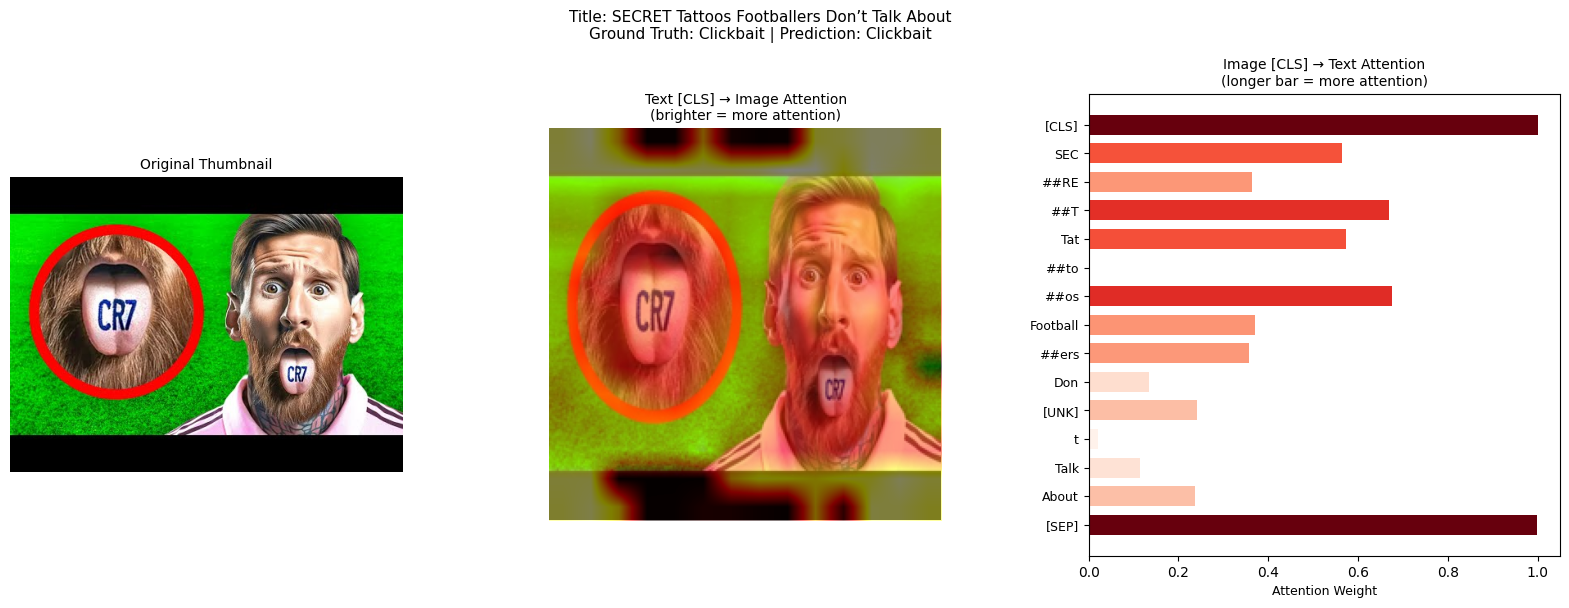

Saved: /content/drive/MyDrive/clickbait_project/viz_normal.png


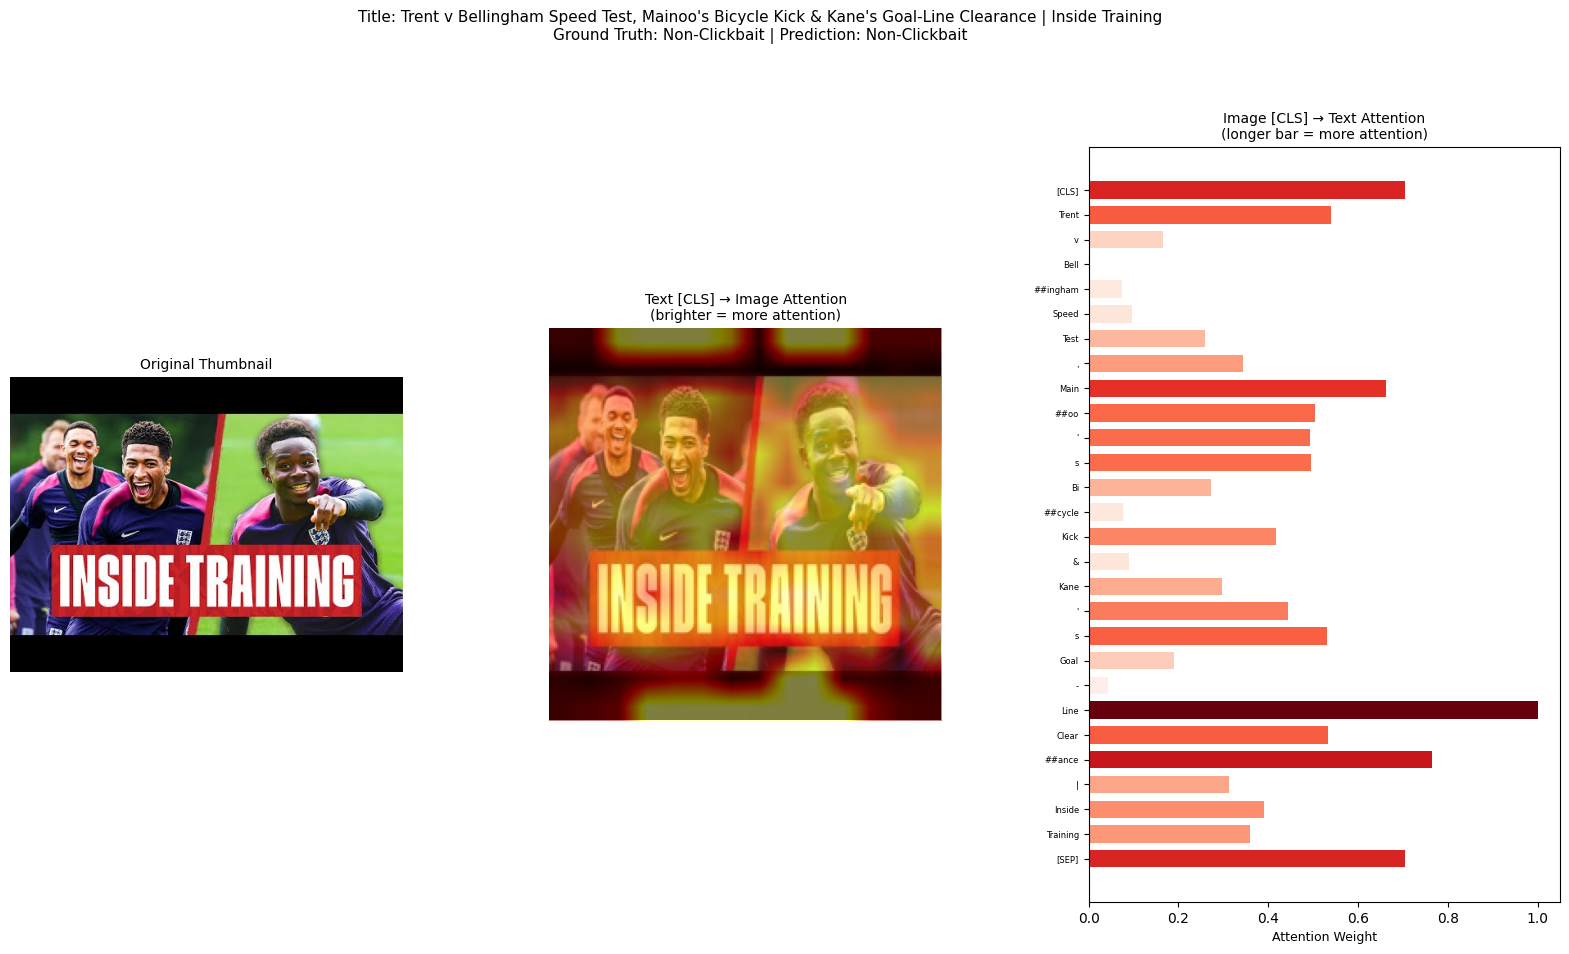

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from PIL import Image
import torch

def visualize_cross_attention(model, tokenizer, image_processor, sample_row, device, img_dir, save_path=None):
    model.eval()

    title = str(sample_row['title'])
    video_id = sample_row['video_id']
    label = int(sample_row['label'])
    label_str = "Clickbait" if label == 1 else "Non-Clickbait"

    # 텍스트 토크나이징
    text_inputs = tokenizer(
        title,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = text_inputs['input_ids'].to(device)
    attention_mask = text_inputs['attention_mask'].to(device)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    real_len = int(attention_mask[0].sum().item())
    tokens = tokens[:real_len]

    # 이미지 로드
    img_path = f"{img_dir}/{video_id}.jpg"
    image = Image.open(img_path).convert("RGB")
    image_inputs = image_processor(images=image, return_tensors='pt')
    pixel_values = image_inputs['pixel_values'].to(device)

    with torch.no_grad():
        logits, t2i_attn, i2t_attn = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )

    pred = logits.argmax(dim=1).item()
    pred_str = "Clickbait" if pred == 1 else "Non-Clickbait"

    # attention weight 처리
    t2i_np = t2i_attn.cpu().numpy()[0]
    i2t_np = i2t_attn.cpu().numpy()[0]
    if t2i_np.ndim == 3:
        t2i_np = t2i_np.mean(axis=0)
    if i2t_np.ndim == 3:
        i2t_np = i2t_np.mean(axis=0)

    num_patches = 14

    fig_height = max(6, real_len * 0.35)
    fig = plt.figure(figsize=(20, fig_height))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.35)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])

    fig.suptitle(
        f"Title: {title}\nGround Truth: {label_str} | Prediction: {pred_str}",
        fontsize=11, y=1.02
    )

    # --- 원본 이미지 ---
    ax0.imshow(image)
    ax0.set_title("Original Thumbnail", fontsize=10)
    ax0.axis('off')

    # --- t2i: 텍스트 CLS가 이미지 어느 패치에 주목했는지 ---
    cls_row = t2i_np[0]
    img_attn = cls_row[1:]
    img_attn = img_attn[:num_patches * num_patches].reshape(num_patches, num_patches)
    img_attn = (img_attn - img_attn.min()) / (img_attn.max() - img_attn.min() + 1e-8)

    img_resized = image.resize((224, 224))
    ax1.imshow(img_resized)
    ax1.imshow(img_attn, cmap='hot', alpha=0.5,
               extent=[0, 224, 224, 0], interpolation='bilinear')
    ax1.set_title("Text [CLS] → Image Attention\n(brighter = more attention)", fontsize=10)
    ax1.axis('off')

    # --- i2t: 이미지 CLS가 텍스트 어느 단어에 주목했는지 ---
    img_cls_row = i2t_np[0, :real_len]
    img_cls_row = (img_cls_row - img_cls_row.min()) / (img_cls_row.max() - img_cls_row.min() + 1e-8)

    colors = plt.cm.Reds(img_cls_row)
    ax2.barh(range(real_len), img_cls_row, color=colors, height=0.7)
    ax2.set_yticks(range(real_len))
    ax2.set_yticklabels(tokens, fontsize=max(6, min(9, 180 // real_len)))
    ax2.invert_yaxis()
    ax2.set_title("Image [CLS] → Text Attention\n(longer bar = more attention)", fontsize=10)
    ax2.set_xlabel("Attention Weight", fontsize=9)
    ax2.set_xlim(0, 1.05)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()


# ==============================
# 시각화 실행: 클릭베이트 1개, 정상 1개
# ==============================
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

clickbait_sample = test_df[test_df['label'] == 1].iloc[0]
visualize_cross_attention(
    model, tokenizer, image_processor,
    clickbait_sample, device, IMG_DIR,
    save_path=f"{BASE_DIR}/viz_clickbait.png"
)

normal_sample = test_df[test_df['label'] == 0].iloc[0]
visualize_cross_attention(
    model, tokenizer, image_processor,
    normal_sample, device, IMG_DIR,
    save_path=f"{BASE_DIR}/viz_normal.png"
)


살구색(연한색) Attention Weight 낮음 = 덜 주목
주황빨간색  = Attention Weight 중간
진한빨강 , 진한 갈색 / 암적색 = Atention Weight높음 많이 주목

텍스트 CLS 토큰이 이미지 패치들 중에서 어디에 집중했는지를 이미지 위에 오버레이해서 보여주는 것